<a href="https://colab.research.google.com/github/asustayta/MATH-CSCI485_Anna_Sustayta/blob/assignment3/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

#  MATH/CSCI 485 Assignment #3:
## Image Compression via Block-wise SVD
Anna Sustayta

---

# Objective

You are to explore the use of Singular Value Decomposition (SVD) for compressing grayscale images. The goal is to apply block-wise SVD, retaining only the top-𝑘 singular values in each block, and to analyze how image quality and compression ratio evolve with $k \in {1,2,..,8}$ .

# Tasks

## 1. Preprocessing

  -  Choose any image of your choice (recommended: 256×256 or 512×512 resolution).

  - Convert it to grayscale (if needed) and crop/resize so both dimensions are divisible by 8.
  


Originial image shape:  (225, 225)
Cropped image shape:  (224, 224)


<function matplotlib.pyplot.show(close=None, block=None)>

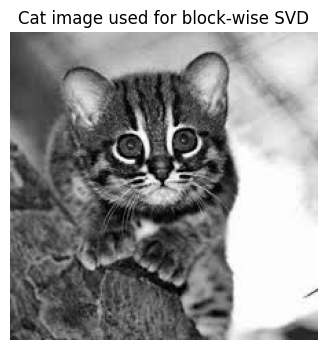

In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image_path = "Cats.jpeg"
BLOCK_SIZE = 8

# load image and convert to gray scale
img=Image.open(image_path).convert('L') #l = grayscale
A_orig= np.array(img, dtype=np.float64)

rows, cols = A_orig.shape
cropped_rows = rows- (rows % BLOCK_SIZE)
cropped_cols = cols - (cols % BLOCK_SIZE)
A = A_orig[:cropped_rows, :cropped_cols]

print("Originial image shape: ", A_orig.shape)
print("Cropped image shape: ", A.shape)

plt.figure(figsize=(6,4))
plt.imshow(A, cmap = "gray")
plt.title("Cat image used for block-wise SVD")
plt.axis("off")
plt.show

## 2. Block-wise SVD Function

 The image is partition into non-overlaping 8x8 blocks, in which each block, a singular value decomposition is applied for $B=UΣV^T$.  Only the top-$k$ singular values were stored to compress the block, for $B_k=U_kΣ_kV_k^T$. In which
 $$U_k \text{ contains the first k columns of }U\\
 Σ_k \text{ contains the top k singular values} \\
 V^T_k \text{ contains the first k rows of} V^T$$
to produce a rank-k approximation of the original image. These reconstructed blocks will be recombined to produce the final compressed image.


In [77]:
def compress_block(block, k):
  U, S, VT = np.linalg.svd(block, full_matrices= False)
  block_k = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
  return block_k

def blockwise_svd_compress (image_array, k , block_size = 8):
  rows, cols = image_array.shape
  reconstructed = np.zeros((rows,cols))

  for i in range(0, rows, block_size):
    for j in range(0, cols, block_size):
      block = image_array[i:i+block_size, j:j+block_size]
      reconstructed[i:i+block_size, j:j+block_size] = compress_block(block, k)
  return reconstructed

def compress_ratio(block_size, k):
  original_values = block_size * block_size
  retained_values = k * (block_size + block_size + 1)
  return original_values / retained_values

def frobenius_error(original, reconstructed):
  return np.linalg.norm(original - reconstructed, ord ="fro")

def psnr(original, reconstructed):
  mse = np.mean((original -reconstructed) ** 2)
  if mse == 0:
    return np.inf
  max_pixel = 255.0
  return 20 * np.log10(max_pixel / np.sqrt(mse))

## 3. Compression Analysis

With an $8 \times 8$ block we have 64 values, and with SVD's $A = U \Sigma V^T$ we have

 $$U_K : 8 × k \\ ∑_k: k \text{ values} \\ V^T_k:k \times 8$$

 , and the number of stored values per block is $$k(8+8+1)=17k$$. With this we get the compression ratio is $CR=\frac{64}{17k}$.

In [78]:
results =[]

for k in range(1, 9):
  Ak = blockwise_svd_compress(A, k , block_size = BLOCK_SIZE)
  cr = compress_ratio(BLOCK_SIZE, k)
  err = frobenius_error (A, Ak)
  peak_snr = psnr(A, Ak)

  results.append({
      "k": k,
      "reconstructed": Ak,
      "compression_ratio": cr,
      "frobenius_error": err,
      "psnr" : peak_snr
  })

for item in results:
     print (f"k = {item['k']}: "
        f"Compression Ratio = {item['compression_ratio']:.4f}, "
        f"Frobenius Error = {item['frobenius_error']:.2f}, "
        f"PSNR = {item ['psnr']:.2f} dB")

k = 1: Compression Ratio = 3.7647, Frobenius Error = 3234.39, PSNR = 24.94 dB
k = 2: Compression Ratio = 1.8824, Frobenius Error = 1632.57, PSNR = 30.88 dB
k = 3: Compression Ratio = 1.2549, Frobenius Error = 859.37, PSNR = 36.45 dB
k = 4: Compression Ratio = 0.9412, Frobenius Error = 448.76, PSNR = 42.10 dB
k = 5: Compression Ratio = 0.7529, Frobenius Error = 195.14, PSNR = 49.33 dB
k = 6: Compression Ratio = 0.6275, Frobenius Error = 69.04, PSNR = 58.35 dB
k = 7: Compression Ratio = 0.5378, Frobenius Error = 19.52, PSNR = 69.33 dB
k = 8: Compression Ratio = 0.4706, Frobenius Error = 0.00, PSNR = 298.39 dB



## 4. Visualization


The reconstruction error is measured using the Frobenius norm with the formula $$||A-A_k||^2_F$$
In which $A$ is the original image, and $A_k$ is the reconstructed image using rank-k approximations. This measures how muchinformation is lost by discarding the smaller singular values.
The Peak Signal to Noise Ratio is used to compare the vision quality and we can use the formula $PSNR = 20 \log_{10}\frac{MAX}{\sqrt{MSE}}$ where MAX is 255 and the MSE is the mean squared error between the two images. The higher PSNR values show that the reconstruction image is of better quality.

<function matplotlib.pyplot.show(close=None, block=None)>

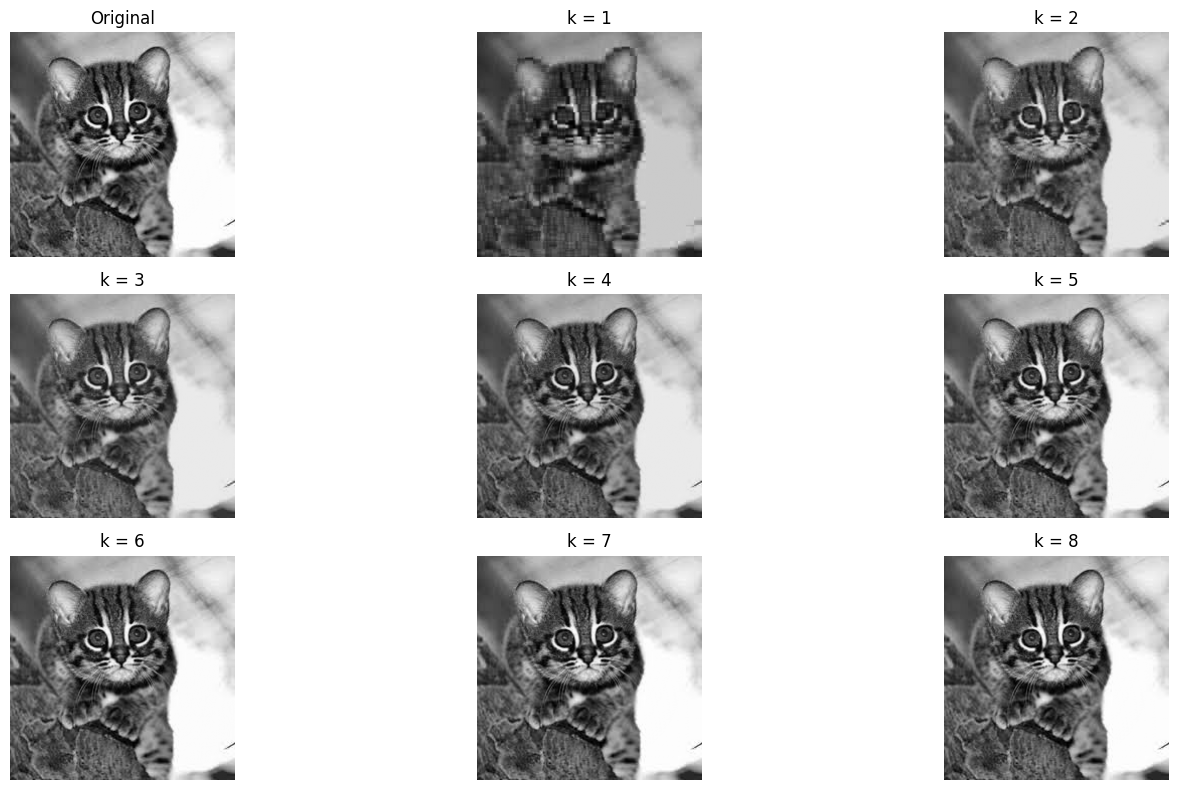

In [79]:
plt.figure(figsize=(16,8))
plt.subplot(3,3,1)
plt.imshow(A, cmap="gray")
plt.title("Original")
plt.axis("off")

for idx, item in enumerate(results, start =2):
  plt.subplot(3,3,idx)
  plt.imshow(item["reconstructed"], cmap="gray")
  plt.title(f"k = {item['k']}")
  plt.axis("off")

plt.tight_layout()
plt.show

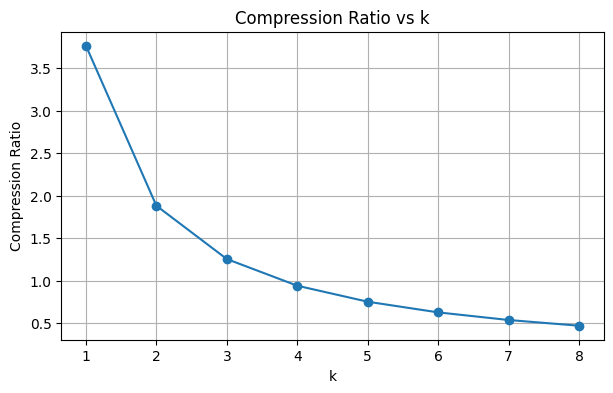

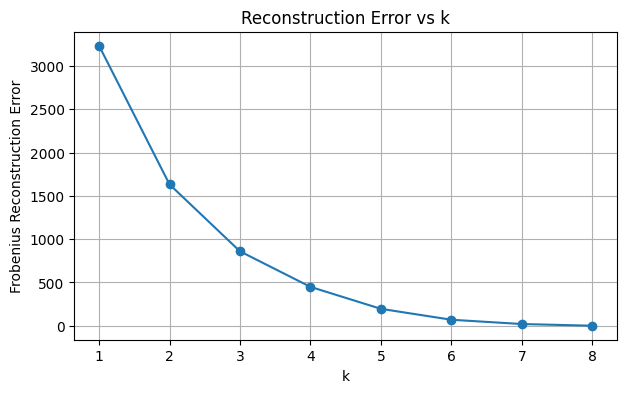

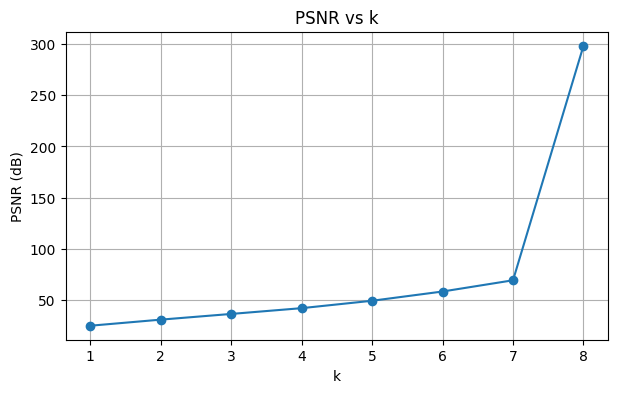

In [80]:
k_val = [item["k"] for item in results]
compr_vals = [item["compression_ratio"] for item in results]
error_vals = [item["frobenius_error"] for item in results]
psnr_vals = [item["psnr"] for item in results]

plt.figure(figsize=(7,4))
plt.plot(k_val, compr_vals, marker = 'o')
plt.xlabel("k")
plt.ylabel("Compression Ratio")
plt.title("Compression Ratio vs k")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(k_val, error_vals, marker = 'o')
plt.xlabel("k")
plt.ylabel("Frobenius Reconstruction Error")
plt.title("Reconstruction Error vs k")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(k_val, psnr_vals, marker = 'o')
plt.xlabel("k")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs k")
plt.grid(True)
plt.show ()

The graphs produced using the Single Value Decomposition verify what we have learned to be the trade offs using this method. When $k$ is small, the compression ratio is larger because there are less values stored per block, but the image looks blurrier and the reconstruction error is high. However, when k increases the image quality improves because more singular value information is stored, and thus the PSNR increases. The Frobenius error also decreases as $k$ increases. Overall, SVD is an effective way to study image compression as it reduces dimesionality.

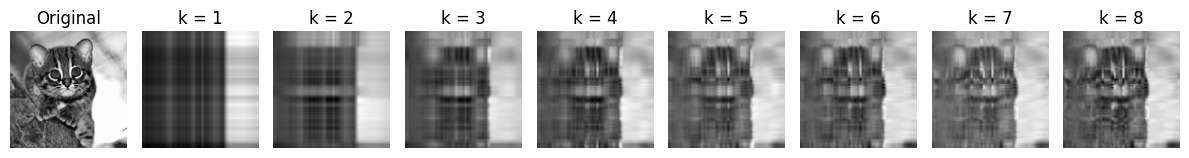

In [85]:
# Extra: Testing out the Whole image for svd without blocks

def svd_blur(image_path, k_values=range(1,9)):
    # Load image and convert to grayscale
    img = Image.open(image_path).convert('L')  # 'L' = grayscale
    A = np.array(img, dtype=np.float64)

    # Apply SVD
    U, S, VT = np.linalg.svd(A, full_matrices=False)

    # Plot original
    plt.figure(figsize=(12, 3))
    plt.subplot(1, len(k_values)+1, 1)
    plt.imshow(A, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstruct with different k
    for idx, k in enumerate(k_values, start=2):
        Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
        plt.subplot(1, len(k_values)+1, idx)
        plt.imshow(Ak, cmap='gray')
        plt.title(f'k = {k}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
svd_blur(image_path, k_values=range(1,9))


In [86]:
output_dir="svd.cat.outputs"
os.makedirs(output_dir, exist_ok=True)

Image.fromarray(A.astype(np.uint8)).save(os.path.join(output_dir, "cat_original_cropped.png"))

for item in results:
  filename = os.path.join(output_dir, f"cat_block_svd_k{item['k']}.png")
  Image.fromarray(item["reconstructed"].astype(np.uint8)).save(filename)

print("Saved reconstructed images to: ", output_dir)
print(sorted(os.listdir(output_dir)))

Saved reconstructed images to:  svd.cat.outputs
['cat_block_svd_k1.png', 'cat_block_svd_k2.png', 'cat_block_svd_k3.png', 'cat_block_svd_k4.png', 'cat_block_svd_k5.png', 'cat_block_svd_k6.png', 'cat_block_svd_k7.png', 'cat_block_svd_k8.png', 'cat_original_cropped.png']
